## Problem Definition

In [1]:
# Clearly define what you want to predict
# --- Regression: predict a continuous number ---
# Target: Charges 

# Document your decisions before touching data
problem = {
    "task" :       "regression",          # or "classification"
    "target":      "charges",         # column you predict
    "features":    ["age","sex","bmi","children","smoker","region"],
    "metric" :     ["RMSE","r2 score"],               # how you'll measure success
    "baseline":    "predict mean always"  # dumb baseline to beat
}

for key, value in problem.items():
    print(f"{key} : {value}")

task : regression
target : charges
features : ['age', 'sex', 'bmi', 'children', 'smoker', 'region']
metric : ['RMSE', 'r2 score']
baseline : predict mean always


## Library imports 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import missingno as msno

import warnings
warnings.filterwarnings("ignore")

## Data collection & loading 

In [3]:
df=pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:

print("Shape:", df.shape)           # (rows, cols)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

# Check target distribution
print("\nTarget stats:\n", df["charges"].describe())

Shape: (1338, 7)

Dtypes:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicates: 1

Target stats:
 count     1338.000000
mean     13270.422265
std      12110.011237
min       1121.873900
25%       4740.287150
50%       9382.033000
75%      16639.912515
max      63770.428010
Name: charges, dtype: float64


## Exploratory data analysis

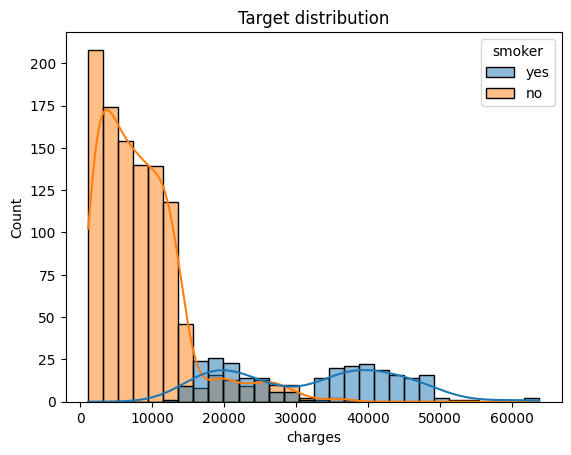

In [5]:
# 1. Distribution of target variable
sns.histplot(df, x=df["charges"],hue='smoker',kde=True)
plt.title("Target distribution")
plt.show()

<Axes: xlabel='charges', ylabel='Count'>

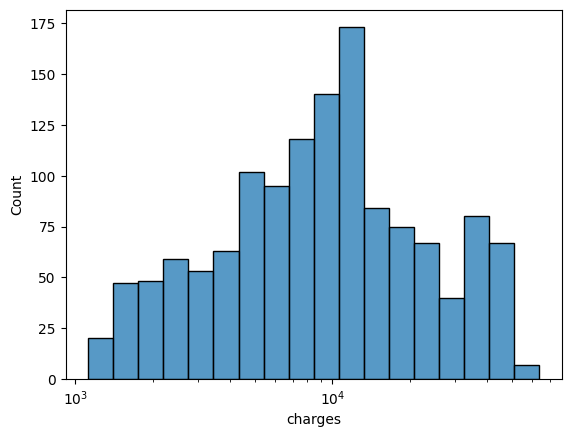

In [6]:
sns.histplot(df, x="charges", log_scale=True)

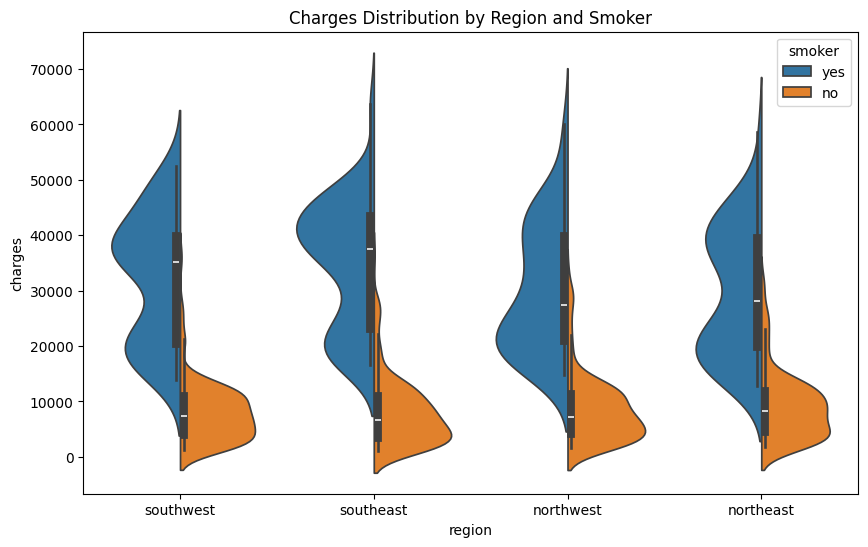

In [7]:
plt.figure(figsize=(10,6))
sns.violinplot(x='region', y='charges', hue='smoker', data=df, split=True)
plt.title('Charges Distribution by Region and Smoker')
plt.show()

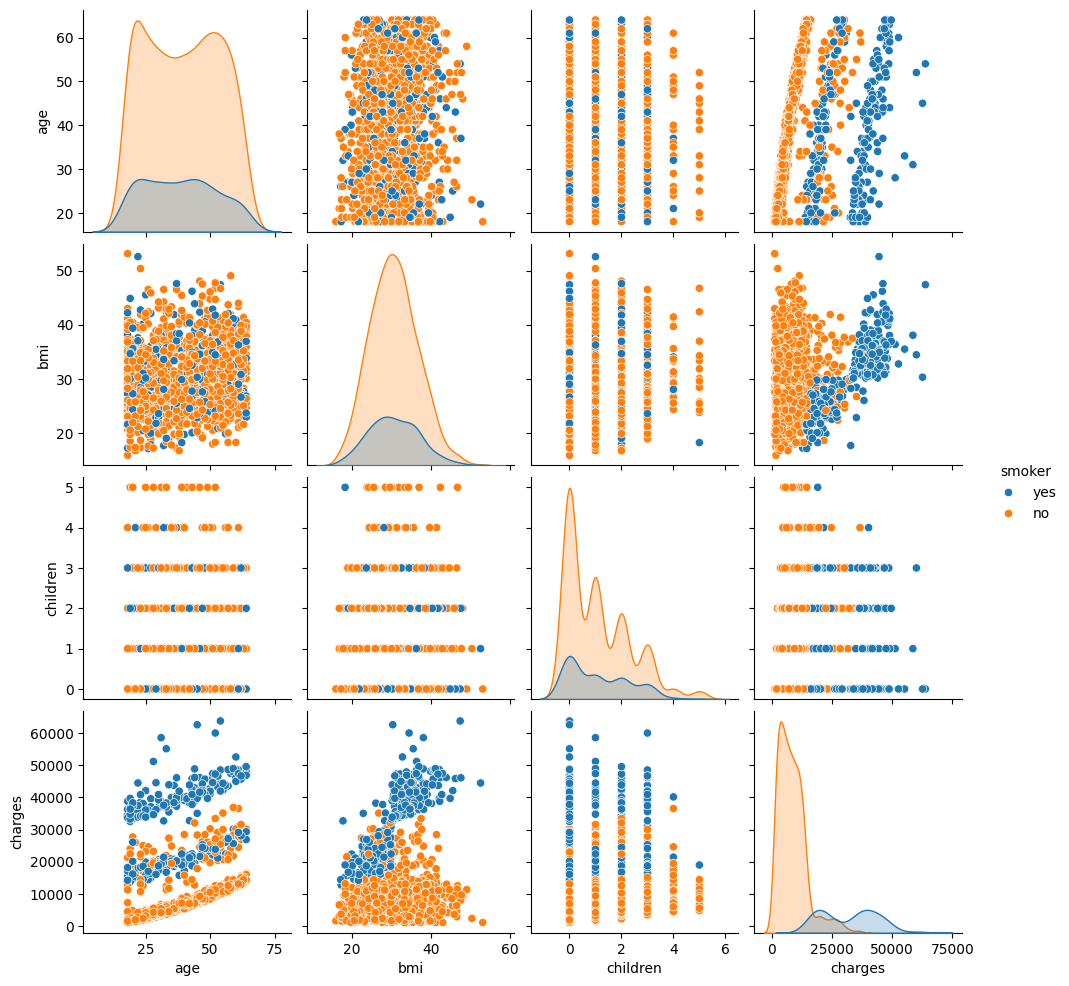

In [8]:
sns.pairplot(df, hue='smoker')
plt.show()

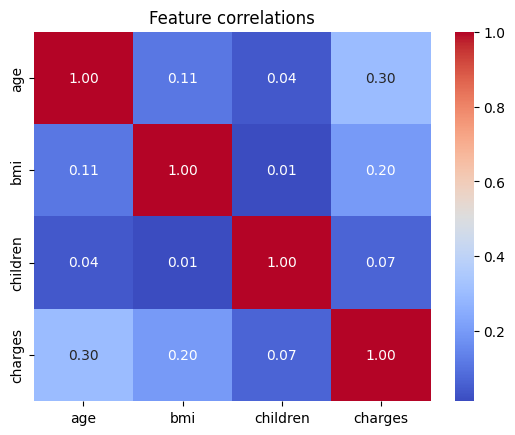

In [9]:
# Correlation matrix — CRITICAL for linear models
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature correlations")
plt.show()

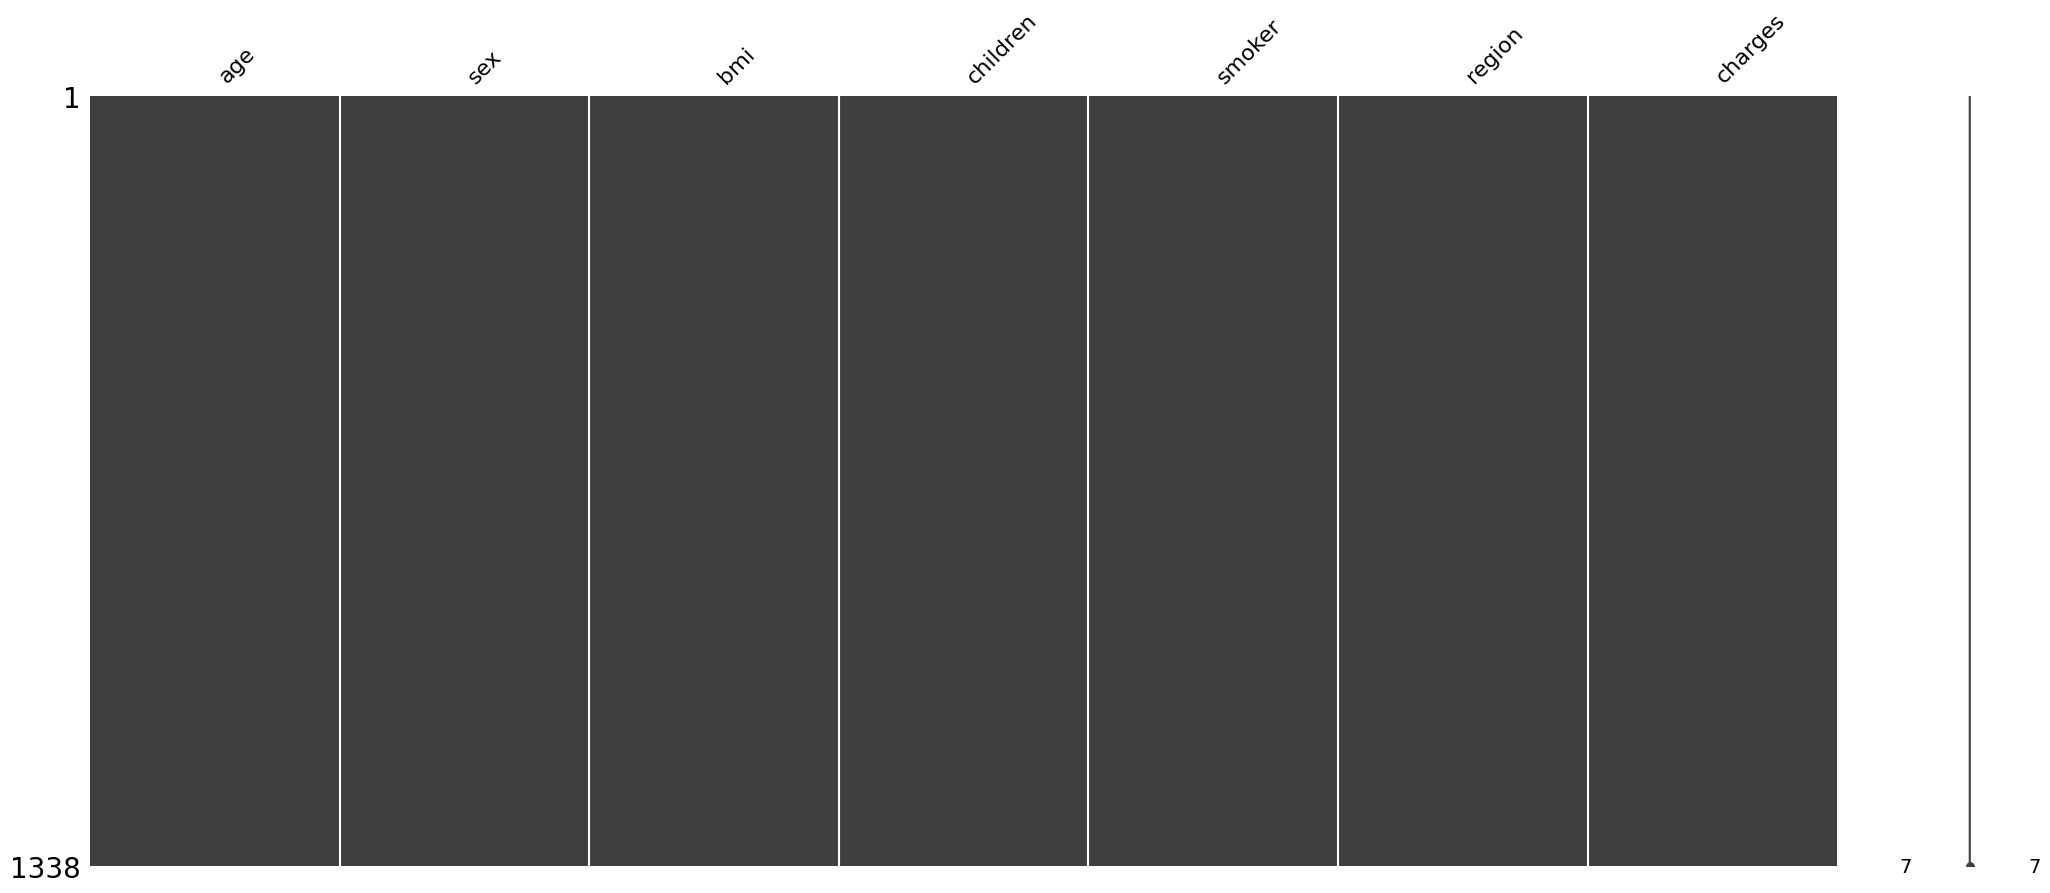

In [10]:
msno.matrix(df)
plt.show()

In [11]:
# Select only numeric columns
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\nColumn: {col}")
    print(f"Outliers count: {outliers.shape[0]}")
    print(outliers)



Column: age
Outliers count: 0
Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: []

Column: bmi
Outliers count: 9
      age     sex    bmi  children smoker     region      charges
116    58    male  49.06         0     no  southeast  11381.32540
286    46  female  48.07         2     no  northeast   9432.92530
401    47    male  47.52         1     no  southeast   8083.91980
543    54  female  47.41         0    yes  southeast  63770.42801
847    23    male  50.38         1     no  southeast   2438.05520
860    37  female  47.60         2    yes  southwest  46113.51100
1047   22    male  52.58         1    yes  southeast  44501.39820
1088   52    male  47.74         1     no  southeast   9748.91060
1317   18    male  53.13         0     no  southeast   1163.46270

Column: children
Outliers count: 0
Empty DataFrame
Columns: [age, sex, bmi, children, smoker, region, charges]
Index: []

Column: charges
Outliers count: 139
      age     sex     bmi  childr

In [12]:
numeric_cols = ['age', 'bmi', 'children', 'charges']

print("=" * 45)
print("   Skewness BEFORE Log Transformation")
print("=" * 45)

for col in numeric_cols:
    skew_val = df[col].skew()
    flag = ""
    if abs(skew_val) > 1.0:
        flag = "HIGHLY SKEWED — apply log"
    elif abs(skew_val) > 0.5:
        flag = "MODERATELY SKEWED — consider log"
    else:
        flag = "Normal — skip log"
    print(f"  {col:<12} skewness = {skew_val:+.4f}   {flag}")

   Skewness BEFORE Log Transformation
  age          skewness = +0.0557   Normal — skip log
  bmi          skewness = +0.2840   Normal — skip log
  children     skewness = +0.9384   MODERATELY SKEWED — consider log
  charges      skewness = +1.5159   HIGHLY SKEWED — apply log


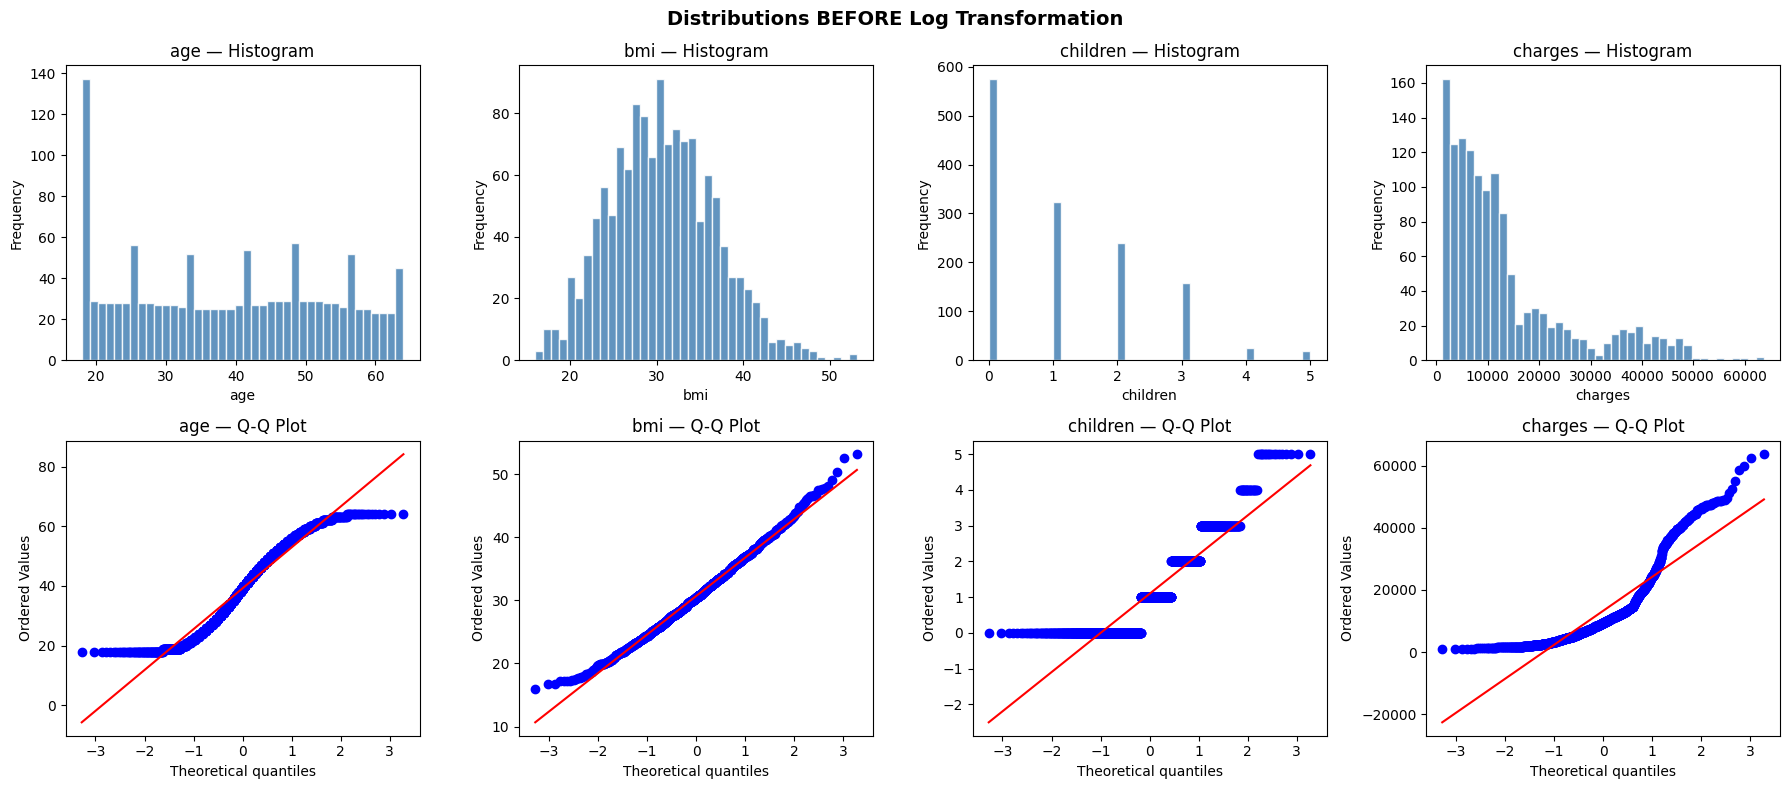

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Distributions BEFORE Log Transformation', 
             fontsize=14, fontweight='bold')

for i, col in enumerate(numeric_cols):
    # Histogram
    axes[0, i].hist(df[col], bins=40, color='steelblue', 
                    edgecolor='white', alpha=0.85)
    axes[0, i].set_title(f'{col} — Histogram')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frequency')

    # Q-Q Plot (points on diagonal line = normal distribution)
    stats.probplot(df[col], dist="norm", plot=axes[1, i])
    axes[1, i].set_title(f'{col} — Q-Q Plot')

plt.tight_layout()
plt.savefig('before_log_transform.png', dpi=150, bbox_inches='tight')
plt.show()


Column: sex
sex
male      676
female    662
Name: count, dtype: int64

Percentage:
sex
male      50.523169
female    49.476831
Name: proportion, dtype: float64


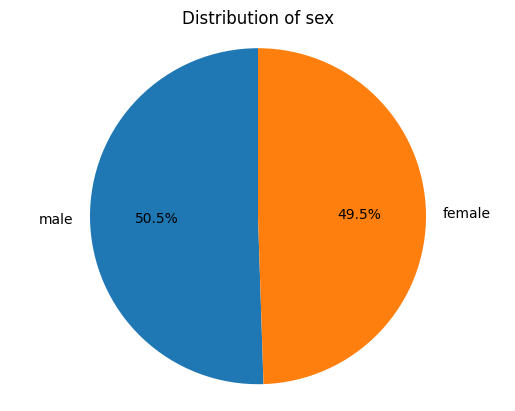


Column: smoker
smoker
no     1064
yes     274
Name: count, dtype: int64

Percentage:
smoker
no     79.521674
yes    20.478326
Name: proportion, dtype: float64


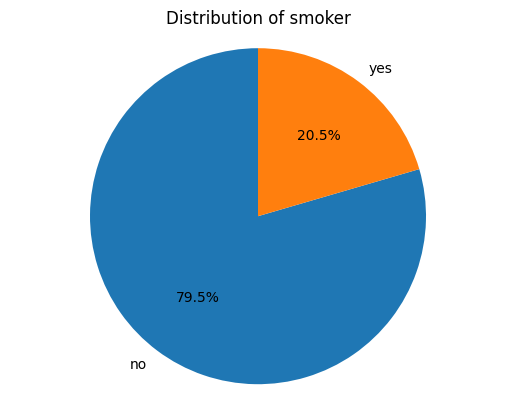


Column: region
region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

Percentage:
region
southeast    27.204783
southwest    24.289985
northwest    24.289985
northeast    24.215247
Name: proportion, dtype: float64


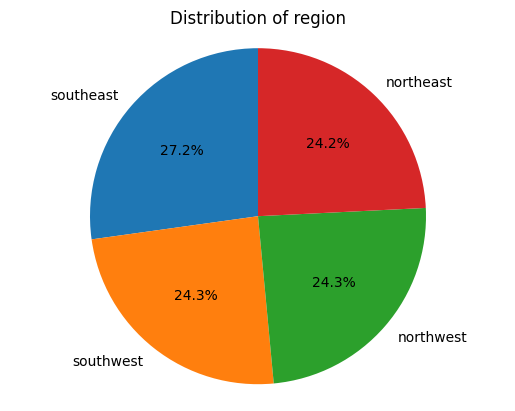

In [14]:
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    
    # Step 1: Show counts
    counts = df[col].value_counts()
    print(counts)
    
    # Step 2: Show percentages
    percentages = df[col].value_counts(normalize=True) * 100
    print("\nPercentage:")
    print(percentages)
    
    # Step 3: Pie Chart
    plt.figure()
    plt.pie(counts, labels=counts.index, autopct='%1.1f%%', startangle=90)
    plt.title(f"Distribution of {col}")
    plt.axis('equal')
    
    plt.show()

## Data preprocessing 

In [15]:
#  skewness check before anything 
print(f"\nCharges skewness (raw)    : {df['charges'].skew():.4f}")
print(f"Charges skewness (log)    : {np.log(df['charges']).skew():.4f}")
print(f"Children skewness (raw)   : {df['children'].skew():.4f}")

# children skewness < 1 → treat as category, NOT log transform
# charges skewness > 1  → must use log(charges)


Charges skewness (raw)    : 1.5159
Charges skewness (log)    : -0.0901
Children skewness (raw)   : 0.9384


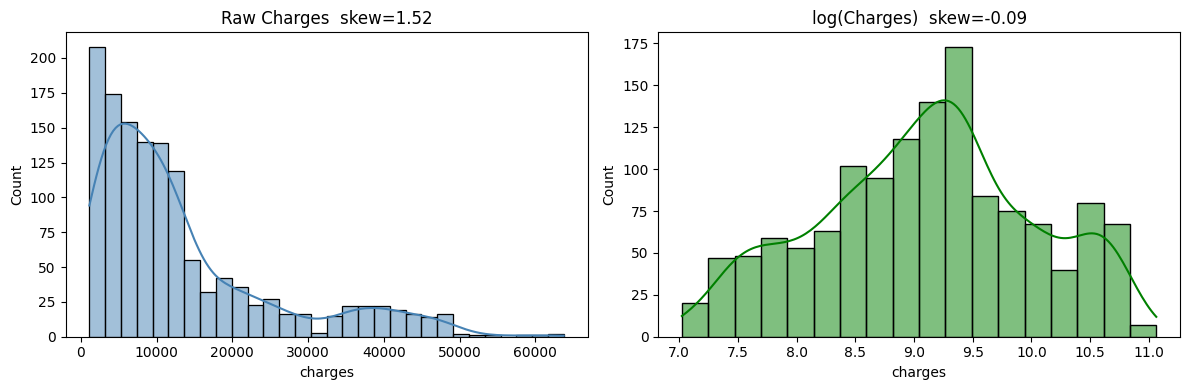

In [16]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.histplot(df['charges'], kde=True, color='steelblue')
plt.title(f"Raw Charges  skew={df['charges'].skew():.2f}")


plt.subplot(1, 2, 2)
sns.histplot(np.log(df['charges']), kde=True, color='green')
plt.title(f"log(Charges)  skew={np.log(df['charges']).skew():.2f}")
plt.tight_layout()
plt.savefig("skewness_check.png", dpi=150)
plt.show()

#  Remove duplicates 

In [17]:
df = df.drop_duplicates().reset_index(drop=True)

# Outlier Removal

In [18]:
features_cols_for_outlier_check = ['age','bmi']
numeric_features =df[features_cols_for_outlier_check]

# Compute Z-scores
z = np.abs(stats.zscore(numeric_features))

# Detect outliers from ORIGINAL df
outliers = df[(z >= 3).any(axis=1)]

# Create cleaned dataset
df_clean = df[(z < 3).all(axis=1)]

print("Outliers:")
print(outliers.shape)

print("\nCleaned Data:")
print(df_clean.shape)

Outliers:
(4, 7)

Cleaned Data:
(1333, 7)


# Feature engineering

In [19]:
df_clean = df_clean.copy() 

# ── Keep this (you already have it) ──────────────────────
df_clean["smoker_yes"] = df_clean["smoker"].map({"yes": 1, "no": 0})

# Polynomial terms
df_clean["age2"]       = df_clean["age"] ** 2          
df_clean["bmi2"]       = df_clean["bmi"] ** 2          

# Obesity flag — BMI >= 30 is a hard pricing threshold
df_clean['obese']        = (df_clean['bmi'] >= 30).astype(int) 


# Interaction terms — smoker x bmi is the biggest driver of charges

df_clean['smoker_obese'] = df_clean['smoker_yes'] * df_clean['obese']   
df_clean["smoker_bmi"] = df_clean["bmi"] * df_clean["smoker_yes"]
df_clean["smoker_age"] = df_clean["smoker_yes"] * df_clean["age"] 
df_clean["smoker_bmi2"]  = df_clean["smoker_yes"] * df_clean["bmi2"]
df_clean["age_bmi"]    = df_clean["age"] * df_clean["bmi"]


df_clean["children_cat"] = df_clean["children"].astype(str)

# Age group binning
df_clean["age_group"]  = pd.cut(df_clean["age"], bins=[0,30,50,100],
                                 labels=["young","adult","old"])



# ── Explicit risk group features ────────────────────────────
df_clean["risk_group"] = "low"
df_clean.loc[
    (df_clean["smoker_yes"] == 1) & (df_clean["bmi"] < 30),
    "risk_group"
] = "medium"
df_clean.loc[
    (df_clean["smoker_yes"] == 1) & (df_clean["bmi"] >= 30),
    "risk_group"
] = "high"

print("Cluster distribution:")
print(df_clean["risk_group"].value_counts())


print("All features:", df_clean.columns.tolist())

Cluster distribution:
risk_group
low       1060
high       144
medium     129
Name: count, dtype: int64
All features: ['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'smoker_yes', 'age2', 'bmi2', 'obese', 'smoker_obese', 'smoker_bmi', 'smoker_age', 'smoker_bmi2', 'age_bmi', 'children_cat', 'age_group', 'risk_group']


#   Split BEFORE imputing (critical) 

In [20]:

from sklearn.model_selection import train_test_split
X = df_clean.drop(["children","charges","smoker"], axis=1)
y = np.log(df_clean["charges"])

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.20, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42)


## Piple line Creation 
## one hot Encoding 
## Scaling 
## imputation 

In [21]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object","category"]).columns

print("\nNumeric features    :", num_cols)
print("Categorical features:", cat_cols)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer",SimpleImputer(strategy="median")),
            ("scaler",StandardScaler())]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")
print(num_cols)


Numeric features    : Index(['age', 'bmi', 'smoker_yes', 'age2', 'bmi2', 'obese', 'smoker_obese',
       'smoker_bmi', 'smoker_age', 'smoker_bmi2', 'age_bmi'],
      dtype='object')
Categorical features: Index(['sex', 'region', 'children_cat', 'age_group', 'risk_group'], dtype='object')
Train: (1066, 16), Val: (133, 16), Test: (134, 16)
Index(['age', 'bmi', 'smoker_yes', 'age2', 'bmi2', 'obese', 'smoker_obese',
       'smoker_bmi', 'smoker_age', 'smoker_bmi2', 'age_bmi'],
      dtype='object')


# Model selection

In [22]:
# FIND BEST K FOR SelectKBest

print("\nFinding best K for SelectKBest...")
print(f"{'K':<6} {'Mean R²':<12} {'Std R²':<10} {'Status'}")
print("-" * 40)

best_k    = 10
best_mean = 0

for k in [8, 10, 12, 15, 18, 20]:
    m = Pipeline([
        ("preprocessing", preprocessor),
        ("selector",      SelectKBest(f_regression, k=k)),
        ("regressor",     LinearRegression())
    ])
    cv = cross_val_score(m, X_train, y_train, cv=5, scoring="r2")
    status = "Best so far" if cv.mean() > best_mean else ""
    print(f"k={k:<4} Mean={cv.mean():.4f}   Std={cv.std():.4f}   {status}")
    if cv.mean() > best_mean:
        best_mean = cv.mean()
        best_k    = k

print(f"\nBest K = {best_k}  (Mean R² = {best_mean:.4f})")


Finding best K for SelectKBest...
K      Mean R²      Std R²     Status
----------------------------------------
k=8    Mean=0.7962   Std=0.0261   Best so far
k=10   Mean=0.8012   Std=0.0237   Best so far
k=12   Mean=0.8015   Std=0.0236   Best so far
k=15   Mean=0.8153   Std=0.0223   Best so far
k=18   Mean=0.8150   Std=0.0236   
k=20   Mean=0.8163   Std=0.0230   Best so far

Best K = 20  (Mean R² = 0.8163)


In [23]:
#  FINAL MODEL WITH BEST K 
model = Pipeline([
    ("preprocessing", preprocessor),
    ("selector",      SelectKBest(f_regression, k=best_k)),
    ("regressor",     LinearRegression())
])



# Model Training 

In [24]:
model.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('selector', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transf

In [25]:
#  PREDICT IN LOG SCALE 
y_pred_log_train = model.predict(X_train)
y_pred_log_test  = model.predict(X_test)


In [26]:
# CONVERT BACK TO ACTUAL CHARGES 
# Model was trained on log(charges)
# np.exp() reverses the log → gives real dollar predictions
y_pred_train_actual = np.exp(y_pred_log_train)
y_pred_test_actual  = np.exp(y_pred_log_test)
y_train_actual      = np.exp(y_train)
y_test_actual       = np.exp(y_test)


In [27]:
print("\nSample Predictions (in actual dollars):")
print("-" * 45)
sample_df = pd.DataFrame({
    "Actual Charges ($)"   : y_test_actual.values[:10].round(2),
    "Predicted Charges ($)": y_pred_test_actual[:10].round(2),
    "Error ($)"            : np.abs(
                                y_test_actual.values[:10] -
                                y_pred_test_actual[:10]
                             ).round(2)
})
print(sample_df.to_string(index=False))


Sample Predictions (in actual dollars):
---------------------------------------------
 Actual Charges ($)  Predicted Charges ($)  Error ($)
           24476.48               10690.69   13785.78
           11576.13               13227.45    1651.32
            8932.08                9077.14     145.06
           11938.26               12278.84     340.59
            4189.11                4461.69     272.58
            7222.79                7183.71      39.07
            6184.30                6090.63      93.67
           18246.50               19158.89     912.39
            3956.07                4375.24     419.17
            3171.61                3778.04     606.43


# Evaluation & diagnostics

In [28]:
#  EVALUATE ─────────────────────────────────────────
# R² computed on log scale (standard practice)
train_r2 = r2_score(y_train, y_pred_log_train)
test_r2  = r2_score(y_test,  y_pred_log_test)
gap      = abs(train_r2 - test_r2)
print(gap)

# Gap > 0.05  → Overfitting  → increase regularisation, reduce features
# Gap < 0.01  → Underfitting → add more features, try complex model
# Gap 0.01–0.05 → Perfect balance 

0.010422786750622581


In [29]:
# MAE computed on actual dollar scale (for business interpretation)
mae_dollars  = mean_absolute_error(y_test_actual,  y_pred_test_actual)
rmse_dollars = np.sqrt(mean_squared_error(y_test_actual, y_pred_test_actual))

print("\n" + "="*50)
print("MODEL EVALUATION")
print("="*50)
print(f"Train R²           : {train_r2:.4f}")
print(f"Test  R²           : {test_r2:.4f}")
print(f"Train-Test gap     : {gap:.4f}")
print(f"MAE  (dollars)     : ${mae_dollars:,.2f}  (avg prediction error)")
print(f"RMSE (dollars)     : ${rmse_dollars:,.2f}")



MODEL EVALUATION
Train R²           : 0.8192
Test  R²           : 0.8088
Train-Test gap     : 0.0104
MAE  (dollars)     : $2,631.50  (avg prediction error)
RMSE (dollars)     : $5,151.90


In [30]:
#CROSS VALIDATION ─────────────────────────────────
cv_scores = cross_val_score(model, X_train , y_train, cv=5, scoring="r2")
print(f"\n5-Fold CV Scores   : {np.round(cv_scores, 4)}")
print(f"CV Mean R²         : {cv_scores.mean():.4f}")
print(f"CV Std R²          : {cv_scores.std():.4f}")  



5-Fold CV Scores   : [0.7711 0.835  0.8272 0.8264 0.822 ]
CV Mean R²         : 0.8163
CV Std R²          : 0.0230


In [31]:
# RESIDUAL CHECK ───────────────────────────────────
residuals = y_test - y_pred_log_test

print(f"Residual mean      : {residuals.mean():.4f}  "
      f"{'close to 0' if abs(residuals.mean()) < 0.01 else ''}")
print(f"Residual skewness  : {pd.Series(residuals).skew():.4f}")


Residual mean      : 0.0164  
Residual skewness  : 3.0653


In [32]:
# SELECTED FEATURES 
selected_mask  = model.named_steps["selector"].get_support()
all_feat_names = model.named_steps["preprocessing"].get_feature_names_out()
selected_feats = all_feat_names[selected_mask]
scores         = model.named_steps["selector"].scores_[selected_mask]

feat_df = pd.DataFrame({
    "feature": selected_feats,
    "score":   scores
}).sort_values("score", ascending=False)

print(f"\nTop selected features (k={best_k}):")
print(feat_df.to_string(index=False))


Top selected features (k=20):
               feature      score
       num__smoker_bmi 898.469430
      num__smoker_bmi2 835.058476
   cat__risk_group_low 823.010459
       num__smoker_yes 823.010459
       num__smoker_age 725.197096
     num__smoker_obese 500.775881
  cat__risk_group_high 500.775881
              num__age 414.170709
             num__age2 375.846584
          num__age_bmi 335.217076
  cat__age_group_young 272.960014
    cat__age_group_old 164.084537
cat__risk_group_medium 113.573936
   cat__children_cat_0  30.554302
              num__bmi  15.977299
             num__bmi2  14.251310
            num__obese  13.919070
   cat__children_cat_3  13.658904
   cat__children_cat_2  12.858609
  cat__age_group_adult  11.804337


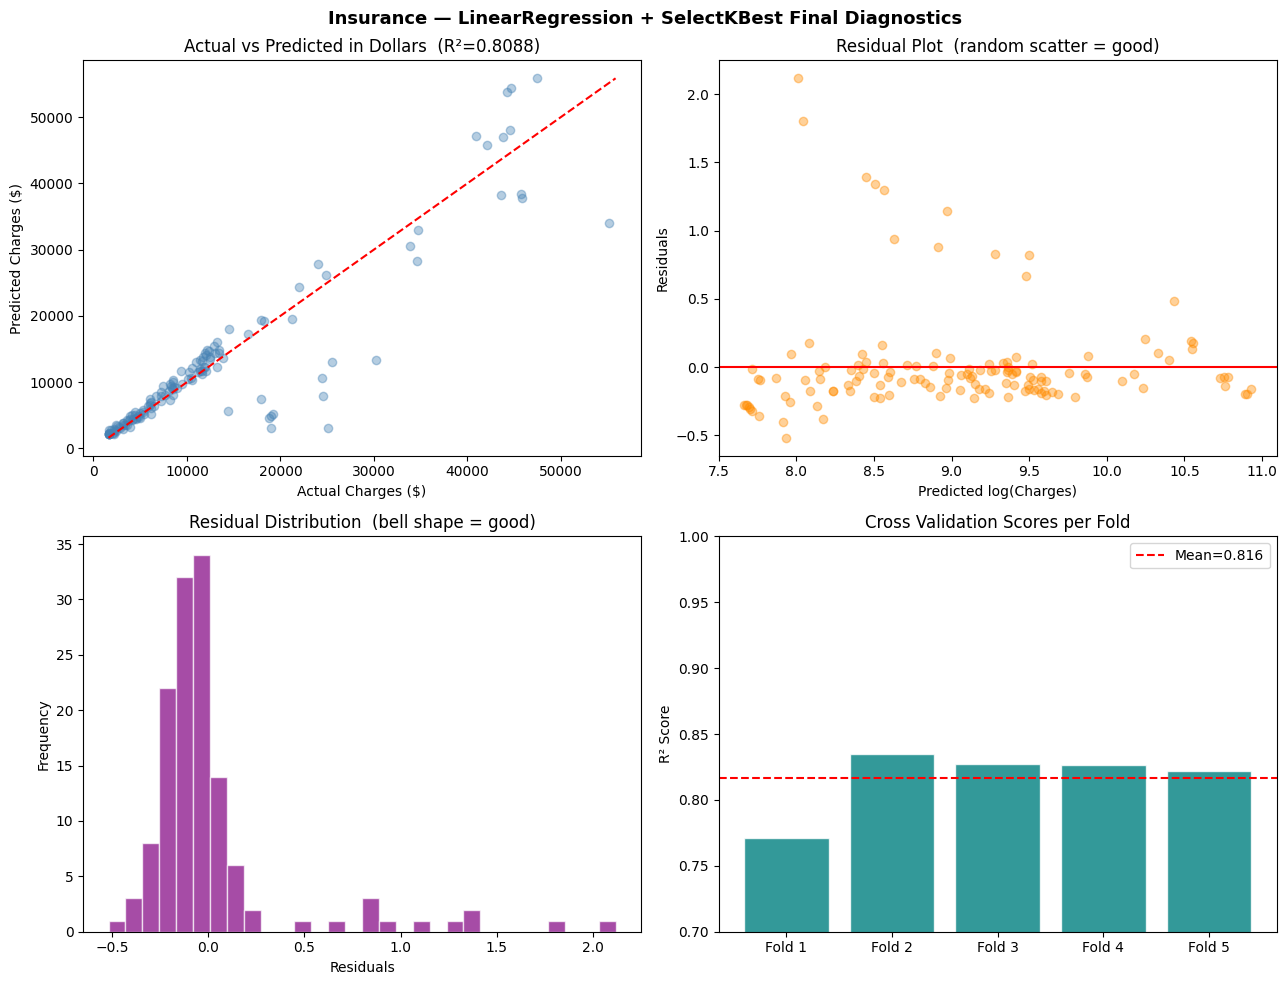

In [33]:
# PLOTS ────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Actual vs Predicted (in actual dollars)
axes[0, 0].scatter(y_test_actual, y_pred_test_actual, alpha=0.4, color='steelblue')
lims = [min(y_test_actual.min(), y_pred_test_actual.min()),
        max(y_test_actual.max(), y_pred_test_actual.max())]
axes[0, 0].plot(lims, lims, "r--", linewidth=1.5)
axes[0, 0].set_xlabel("Actual Charges ($)")
axes[0, 0].set_ylabel("Predicted Charges ($)")
axes[0, 0].set_title(f"Actual vs Predicted in Dollars  (R²={test_r2:.4f})")

# 2. Residual plot (log scale — for model diagnostics)
axes[0, 1].scatter(y_pred_log_test, residuals, alpha=0.4, color='darkorange')
axes[0, 1].axhline(0, color='red', linewidth=1.5)
axes[0, 1].set_xlabel("Predicted log(Charges)")
axes[0, 1].set_ylabel("Residuals")
axes[0, 1].set_title("Residual Plot  (random scatter = good)")

# 3. Residual histogram
axes[1, 0].hist(residuals, bins=30, color='purple', alpha=0.7, edgecolor='white')
axes[1, 0].set_xlabel("Residuals")
axes[1, 0].set_ylabel("Frequency")
axes[1, 0].set_title("Residual Distribution  (bell shape = good)")

# 4. CV scores bar chart
axes[1, 1].bar([f"Fold {i+1}" for i in range(5)],
               cv_scores, color='teal', alpha=0.8, edgecolor='white')
axes[1, 1].axhline(cv_scores.mean(), color='red',
                    linestyle='--', label=f'Mean={cv_scores.mean():.3f}')
axes[1, 1].set_ylabel("R² Score")
axes[1, 1].set_title("Cross Validation Scores per Fold")
axes[1, 1].legend()
axes[1, 1].set_ylim(0.7, 1.0)

plt.suptitle("Insurance — LinearRegression + SelectKBest Final Diagnostics",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("final_diagnostics.png", dpi=150)
plt.show()

In [34]:
# ── FINAL SUMMARY ─────────────────────────────────────────────
print("\n" + "="*50)
print("FINAL SUMMARY")
print("="*50)
print(f"  Model              : LinearRegression + SelectKBest(k={best_k})")
print(f"  Target transform   : log(charges) → exp() for predictions")
print(f"  Children fix       : treated as category (not log1p)")
print(f"  features Added     : age2, bmi2, obese, smoker_obese, smoker_bmi, smoker_bmi2, age_bmi, children_cat, age_group")
print(f"  Cluster fix        : risk_group feature added")
print(f"  Train R²           : {train_r2:.4f}")
print(f"  Test  R²           : {test_r2:.4f}")
print(f"  CV Mean R²         : {cv_scores.mean():.4f}")
print(f"  CV Std R²          : {cv_scores.std():.4f}")
print(f"  Avg error dollars  : ${mae_dollars:,.2f}")
print("="*50)



FINAL SUMMARY
  Model              : LinearRegression + SelectKBest(k=20)
  Target transform   : log(charges) → exp() for predictions
  Children fix       : treated as category (not log1p)
  features Added     : age2, bmi2, obese, smoker_obese, smoker_bmi, smoker_bmi2, age_bmi, children_cat, age_group
  Cluster fix        : risk_group feature added
  Train R²           : 0.8192
  Test  R²           : 0.8088
  CV Mean R²         : 0.8163
  CV Std R²          : 0.0230
  Avg error dollars  : $2,631.50
